# XG Boost model to predict receiving yards

### Libraries and parameters

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt
import nfl_data_py as nfl
from datetime import datetime
import numpy as np
current_year = 2025
n_games = 3
week = 18

**Defining the players to use**  
Only using Wide Receivers with at least one season of 300+ yards for training the model

In [2]:
players = nfl.import_players()
print(len(players))
wrs = players[players['position']=='WR']
print(len(wrs))
active = wrs[wrs['last_season']>=2014]
print(len(active))
active = active[['gsis_id', 'display_name']]
years = list(range(2014, current_year))
seasonal = nfl.import_seasonal_data(years=years)
print(len(seasonal))
seasonal = seasonal[seasonal['player_id'].isin(active['gsis_id'].to_list())]
print(len(seasonal))
threshold = 400
seasonal_f = seasonal[seasonal['receiving_yards']>=threshold]
to_use = active[active['gsis_id'].isin(seasonal_f['player_id'].to_list())]
print(len(to_use))
to_use = to_use[to_use['gsis_id'].isin(wrs['gsis_id'].to_list())]
print(len(to_use))

25064
3295
1334


6682
2367
291
291


Getting weekly stats and replacing old team names

In [3]:
weekly = nfl.import_weekly_data(years=years)
#print(weekly.columns)
weekly = weekly[((weekly['season'] <= 2020) & (weekly['week'] <= 17)) | ((weekly['season'] >= 2021) & (weekly['week'] <= 18))]
# Selecting only relevant columns
weekly = weekly[['player_id', 'season', 'week', 'opponent_team',
                 'receptions', 'receiving_yards', 'receiving_tds', 'target_share',
                 'carries', 'rushing_yards', 'rushing_tds']]
games = nfl.import_schedules(years)
games['home_team'] = games['home_team'].replace({'STL':'LA', 'OAK':'LV', 'SD':'LAC'})
games['away_team'] = games['away_team'].replace({'STL':'LA', 'OAK':'LV', 'SD':'LAC'})

Downcasting floats.


Getting game_id and offensive team for weekly stats

In [4]:
#Creating function to find ball team and game_id
def get_game_info(row, df_games):
    year = row["season"]
    week = row["week"]
    opponent = row["opponent_team"]

    candidates = df_games[(df_games["season"] == year) & (df_games["week"] == week)]
    match = candidates[
        (candidates["away_team"] == opponent) | (candidates["home_team"] == opponent)
    ]
    if not match.empty:
        if len(match) > 1:
            print("Not only one match")
        game_id = match.iloc[0]["game_id"]
        # Si el oponente es el away, el balón lo tiene el home
        if match.iloc[0]["away_team"] == opponent:
            ball_team = match.iloc[0]["home_team"]
        else:
            ball_team = match.iloc[0]["away_team"]
        return pd.Series([game_id, ball_team], index=["game_id", "ball_team"])
    else:
        print(f"Did not find game_id for year {year}, week {week}, opponent {opponent}")
        return pd.Series([None, None], index=["game_id", "ball_team"])

#Applying the function to weekly_data
weekly[["game_id", "ball_team"]] = weekly.apply(
    lambda row: get_game_info(row, games),
    axis=1
)

# Numbering the games for each player
weekly["rn"] = (
    weekly
    .groupby("player_id")["game_id"]
    .rank(method="first", ascending=True)
    .astype(int)
)

Offensive and defensive aggregations

In [5]:
#import numpy as np
#Grouping offensive stats
grouped_off = weekly.groupby(['game_id', 'ball_team', 'season', 'week']).agg({
    'receptions':'sum',
    'receiving_yards':'sum',
    'receiving_tds':'sum',
    'carries':'sum',
    'rushing_yards':'sum',
    'rushing_tds':'sum'
}).reset_index()
grouped_off["rn"] = (
    grouped_off
    .groupby("ball_team")["game_id"]
    .rank(method="first", ascending=True)
    .astype(int)
)
#print(grouped_off.columns)

#Getting season average befor a game
cols = ['receptions', 'receiving_yards', 'receiving_tds', 'carries', 'rushing_yards', 'rushing_tds']
g = grouped_off.groupby(["ball_team", "season"], sort=False)
prev_sum = g[cols].transform(lambda x: x.cumsum() - x)
prev_cnt = g.cumcount()
season_avg = prev_sum.div(prev_cnt.replace(0, np.nan), axis=0)
season_avg.columns = [f"off_{c}_season_avg" for c in cols]
grouped_off = pd.concat([grouped_off, season_avg], axis=1)
#print(grouped_off.columns)

# Getting last n games average
grouped_off[[f"off_{c}_last{n_games}" for c in cols]] = (
    grouped_off
    .groupby("ball_team")[cols]
    .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())
)
#print(grouped_off.columns)
rams = grouped_off[(grouped_off['ball_team']=='LA') & (grouped_off['season']==2024)]
rams[['game_id','receiving_yards','off_receiving_yards_last3', 'off_receiving_yards_season_avg']].head(5)

C:\Users\rille\AppData\Local\Temp\ipykernel_25512\857655027.py:33: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())


,game_id,receiving_yards,off_receiving_yards_last3,off_receiving_yards_season_avg
5231,2024_01_LA_DET,317.0,269.333333,NaN
5261,2024_02_LA_ARI,216.0,265.666667,317.000000
5306,2024_03_SF_LA,221.0,232.000000,266.500000
5325,2024_04_LA_CHI,224.0,251.333333,251.333333
5355,2024_05_GB_LA,260.0,220.333333,244.500000


In [6]:
#Grouping defensive stats
grouped_def = weekly.groupby(['game_id', 'opponent_team', 'season', 'week']).agg({
    'receptions':'sum',
    'receiving_yards':'sum',
    'receiving_tds':'sum',
    'carries':'sum',
    'rushing_yards':'sum',
    'rushing_tds':'sum'
}).reset_index()
grouped_def["rn"] = (
    grouped_def
    .groupby("opponent_team")["game_id"]
    .rank(method="first", ascending=True)
    .astype(int)
)
#print(grouped_def.columns)

#Getting season average befor a game
cols = ['receptions', 'receiving_yards', 'receiving_tds', 'carries', 'rushing_yards', 'rushing_tds']
g = grouped_def.groupby(["opponent_team", "season"], sort=False)
prev_sum = g[cols].transform(lambda x: x.cumsum() - x)
prev_cnt = g.cumcount()
season_avg = prev_sum.div(prev_cnt.replace(0, np.nan), axis=0)
season_avg.columns = [f"def_{c}_season_avg" for c in cols]
grouped_def = pd.concat([grouped_def, season_avg], axis=1)
#print(grouped_def.columns)


# Getting last n games average
grouped_def[[f"def_{c}_last{n_games}" for c in cols]] = (
    grouped_def
    .groupby("opponent_team")[cols]
    .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())
)
#print(grouped_def.columns)

C:\Users\rille\AppData\Local\Temp\ipykernel_25512\2435637993.py:33: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())


Getting each receiver stats

In [7]:
weekly_use = weekly[weekly['player_id'].isin(to_use['gsis_id'].to_list())]
print(len(weekly))
print(len(weekly_use))
#print(weekly_use.columns)

# Mike Evans = '00-0031408'

#Getting season average befor a game
cols = ['receptions', 'receiving_yards', 'receiving_tds', 'target_share', 'carries', 'rushing_yards', 'rushing_tds']
g = weekly_use.groupby(["player_id", "season"], sort=False)
prev_sum = g[cols].cumsum().shift(1)
prev_cnt = g.cumcount()
season_avg = prev_sum.div(prev_cnt.replace(0, np.nan), axis=0)
season_avg.columns = [f"{c}_season_avg" for c in cols]
weekly_use = pd.concat([weekly_use, season_avg], axis=1)
#print(weekly_use.columns)

# Getting last n games average
weekly_use[[f"{c}_last{n_games}" for c in cols]] = (
    weekly_use
    .groupby("player_id")[cols]
    .transform(lambda g: g.shift().rolling(n_games, min_periods=1).mean())
)
#print(weekly_use.columns)

# Getting career average
weekly_use[[f"{c}_career" for c in cols]] = (
    weekly_use
    .groupby("player_id")[cols]
    .apply(lambda g: g.shift().expanding(min_periods=1).mean())
    .reset_index(drop=True)
)

57301
17710


C:\Users\rille\AppData\Local\Temp\ipykernel_25512\2505170435.py:30: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda g: g.shift().expanding(min_periods=1).mean())


## Creating the model

### Merging the datasets

In [8]:
#print(grouped_off.columns)
off = grouped_off[['game_id', 'ball_team',
                   'off_receptions_season_avg', 'off_receiving_yards_season_avg','off_receiving_tds_season_avg',
                   'off_carries_season_avg', 'off_rushing_yards_season_avg','off_rushing_tds_season_avg',
                   f'off_receptions_last{n_games}',f'off_receiving_yards_last{n_games}', f'off_receiving_tds_last{n_games}',
                   f'off_carries_last{n_games}', f'off_rushing_yards_last{n_games}', f'off_rushing_tds_last{n_games}']]
wu_off = pd.merge(weekly_use, off, on=['game_id', 'ball_team'], how='inner')
deff = grouped_def[['game_id', 'opponent_team',
                   'def_receptions_season_avg', 'def_receiving_yards_season_avg','def_receiving_tds_season_avg',
                   'def_carries_season_avg', 'def_rushing_yards_season_avg','def_rushing_tds_season_avg',
                   f'def_receptions_last{n_games}',f'def_receiving_yards_last{n_games}', f'def_receiving_tds_last{n_games}',
                   f'def_carries_last{n_games}', f'def_rushing_yards_last{n_games}', f'def_rushing_tds_last{n_games}']]
complete = pd.merge(wu_off, deff, on=['game_id', 'opponent_team'], how='inner')
#print(complete.columns)

Model

Train MSE: 1.1457988023757935
Train MAE: 0.6678458452224731
Train R²: 0.9992145299911499
Test MSE: 1429.3701171875
Test MAE: 28.84665298461914
Test R²: 0.11342597007751465


<Figure size 1000x800 with 0 Axes>

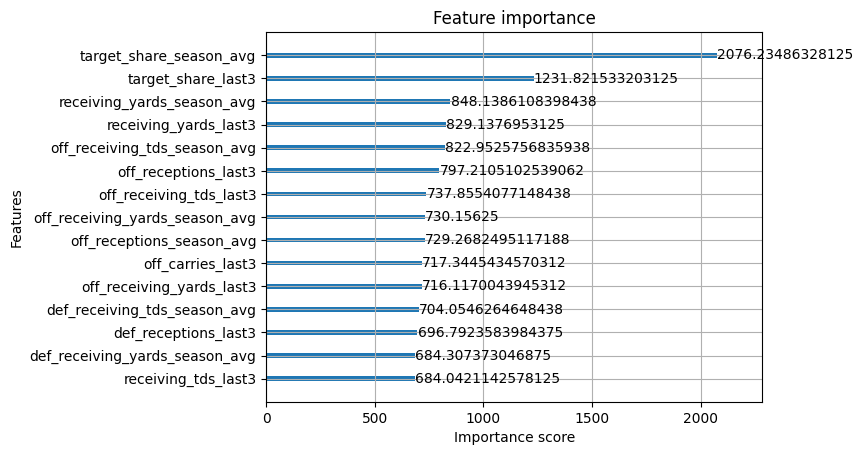

In [9]:
# 1. Definir features y target
features = [
    'receptions_season_avg', 'receiving_yards_season_avg','receiving_tds_season_avg', 'target_share_season_avg',
    'receptions_last3', 'receiving_yards_last3', 'receiving_tds_last3', 'target_share_last3',
    'receptions_career','receiving_yards_career', 'receiving_tds_career', 'target_share_career',
    
    'def_receptions_season_avg', 'def_receiving_yards_season_avg', 'def_receiving_tds_season_avg',
    'def_receptions_last3', 'def_receiving_yards_last3','def_receiving_tds_last3',
    
    'off_receptions_season_avg', 'off_receiving_yards_season_avg','off_receiving_tds_season_avg',
    'off_receptions_last3', 'off_receiving_yards_last3','off_receiving_tds_last3', 'off_carries_last3'
    ]

X = complete[features]
y = complete['receiving_yards']

# 2. Train/test split by season (randomly select one season for test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42  # random_state para reproducibilidad
)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
y_train = y_train.fillna(0)
y_test = y_test.fillna(0)
# unique_seasons = complete['season'].unique()
# test_season = np.random.choice(unique_seasons)
# print(f"Test season: {test_season}")

# train_idx = complete['season'] != test_season
# test_idx = complete['season'] == test_season

# X_train, X_test = X[train_idx], X[test_idx]
# y_train, y_test = y[train_idx], y[test_idx]

# 3. Entrenar modelo
model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=84
)
model.fit(X_train, y_train)

# 4. Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 5. Métricas
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

# 6. Importancia de features
plt.figure(figsize=(10,8))
plot_importance(model, max_num_features=15, importance_type='gain')
plt.show()

## Applying model

Getting top 3 players on depth chart

In [10]:
depth_charts = nfl.import_depth_charts(years=[current_year])
# hoy = datetime.today().strftime('%Y-%m-%d')  # uncomment for live/current-week predictions
hoy = '2026-01-04'  # hardcoded for testing week 18 of the 2025 season (games played 2026-01-03/04)
dc = depth_charts[depth_charts['dt'].str.startswith(hoy)]
wrs = dc[dc['pos_abb']=='WR']
#print(wrs.columns)
starters = wrs[wrs['pos_rank']<=3]
starters = starters[['gsis_id', 'player_name', 'team']]
#print(len(starters))

Getting player's stats

In [11]:
pbp = nfl.import_pbp_data(years=[current_year],
                          columns=['game_id', 'play_id', 'penalty', 'aborted_play', 'drive_yards_penalized','penalty_yards',
                                   'play_deleted',
                                   'fantasy_player_name',
                                   'posteam', 'defteam',
                                   'td_player_id', 'pass', 'rush', 'touchdown',
                                   'receiver_player_id', 'receiving_yards', 
                                   'rusher_player_id','rushing_yards',
                                   'fumble', 'interception'],
                          downcast=True, cache=False, alt_path=None)
#pbp = pbp[pbp['penalty']==0]
rushing = pbp.groupby(['rusher_player_id', 'game_id', 'fantasy_player_name']).agg(
    rushing_yards=('rushing_yards','sum'),
    carries=('rushing_yards','count')
).reset_index().rename(columns={'rusher_player_id':'player_id'})
#print(rushing.columns)
receiving = pbp.groupby(['receiver_player_id', 'game_id', 'fantasy_player_name']).agg(
    receiving_yards=('receiving_yards', 'sum'),
    catches=('receiving_yards', 'count'),
    targets=('pass', 'sum')
).reset_index().rename(columns={'receiver_player_id':'player_id'})
#print(receiving.columns)
pbp["receiving_tds"] = np.where((pbp["td_player_id"]==pbp['receiver_player_id']) & (pbp["pass"] == 1) & (pbp['touchdown']==1), 1, 0)
pbp["rushing_tds"]   = np.where((pbp["td_player_id"]==pbp['rusher_player_id']) & (pbp["rush"] == 1) & (pbp['touchdown']==1), 1, 0)
rec_tds = pbp.groupby(['receiver_player_id', 'game_id', 'fantasy_player_name']).agg(
    receiving_tds=('receiving_tds','sum')
).reset_index().rename(columns={'receiver_player_id':'player_id'})
rush_tds = pbp.groupby(['rusher_player_id', 'game_id', 'fantasy_player_name']).agg(
    rushing_tds=('rushing_tds','sum')
).reset_index().rename(columns={'rusher_player_id':'player_id'})
all_stats = pd.merge(rushing, receiving, how='outer', on=['player_id', 'game_id', 'fantasy_player_name'])
all_stats = pd.merge(all_stats, rec_tds, how='outer', on=['player_id', 'game_id', 'fantasy_player_name'])
all_stats = pd.merge(all_stats, rush_tds, how='outer', on=['player_id', 'game_id', 'fantasy_player_name'])
print(all_stats.columns)
all_stats.sort_values(by='receiving_tds',ascending=False).head(5)

2025 done.
Downcasting floats.


Index(['player_id', 'game_id', 'fantasy_player_name', 'rushing_yards',
       'carries', 'receiving_yards', 'catches', 'targets', 'receiving_tds',
       'rushing_tds'],
      dtype='object')


,player_id,game_id,fantasy_player_name,rushing_yards,carries,receiving_yards,catches,targets,receiving_tds,rushing_tds
942,00-0036973,2025_15_NYJ_JAX,T.Etienne,32.0,12.0,73.0,3.0,4.0,3.0,0.0
1370,00-0038563,2025_03_LV_WAS,T.Tucker,4.0,1.0,145.0,8.0,9.0,3.0,0.0
3758,00-0036970,2025_15_ATL_TB,K.Pitts,NaN,NaN,166.0,11.0,13.0,3.0,NaN
3857,00-0037238,2025_09_ATL_NE,D.London,NaN,NaN,118.0,9.0,14.0,3.0,NaN
4129,00-0037816,2025_04_GB_DAL,R.Doubs,NaN,NaN,58.0,6.0,8.0,3.0,NaN


Getting target share from PBP

In [12]:
pbp = nfl.import_pbp_data(years=[current_year])
pbp_pass = pbp[
    (pbp['pass_attempt'] == 1)    # jugada de pase
    & (pbp['receiver_id'].notna()) # hay receptor identificado (target)
    & (pbp['penalty'] == 0)        # sin penalización
    & (pbp['play_type'] == 'pass') # confirmamos tipo de jugada
].copy()
player_targets = (
    pbp_pass.groupby(['game_id', 'posteam', 'defteam', 'receiver_id', 'receiver_player_name'])
    .agg(targets=('play_id', 'nunique'))
    .reset_index()
)
team_targets = (
    pbp_pass.groupby(['game_id', 'posteam', 'defteam'])
    .agg(team_targets=('play_id', 'nunique'))
    .reset_index()
)
target_share = (
    player_targets
    .merge(team_targets, on=['game_id', 'posteam', 'defteam'], how='left')
)
target_share['target_share'] = target_share['targets'] / target_share['team_targets']


2025 done.
Downcasting floats.


Finding game_id and opponent team

In [13]:
schedule = nfl.import_schedules(years=[current_year])
schedule = schedule[schedule['week']==week]
print(starters.columns)
#print(schedule.columns)
#Creating function to find ball team and game_id
byes = set()
def get_id_teams(row, df_games):
    posteam = row['team']
    year = current_year

    candidates = df_games[(df_games["season"] == year) & (df_games["week"] == week)]
    match = candidates[
        (candidates["away_team"] == posteam) | (candidates["home_team"] == posteam)
    ]
    if not match.empty:
        if len(match) > 1:
            print("Not only one match")
        game_id = match.iloc[0]["game_id"]
        # Si el oponente es el away, el balón lo tiene el home
        if match.iloc[0]["away_team"] == posteam:
            opponent_team = match.iloc[0]["home_team"]
        else:
            opponent_team = match.iloc[0]["away_team"]
        return pd.Series([game_id, opponent_team], index=["game_id", "ball_team"])
    else:
        print(f"Did not find game_id for year {year}, week {week}, offense {posteam}")
        byes.add(posteam)
        return pd.Series([None, None], index=["game_id", "ball_team"])

#Applying the function to weekly_data
starters[["game_id", "opponent_team"]] = starters.apply(
    lambda row: get_id_teams(row, schedule),
    axis=1
)
starters = starters.rename(columns={'gsis_id':'player_id', 'team':'ball_team'})
#print(starters.columns)
print(len(starters))
starters = starters[starters['ball_team'].isin(list(byes))==False]
print(len(starters))
#print(starters.columns)


Index(['gsis_id', 'player_name', 'team'], dtype='object')
96
96


Merging stats with target share

In [ ]:
weekly_2025 = weekly[['player_id', 'opponent_team', 'receptions',
       'receiving_yards', 'receiving_tds', 'target_share', 'carries',
       'rushing_yards', 'rushing_tds', 'game_id', 'ball_team']]
weekly_2025 = weekly_2025[sorted(weekly_2025.columns)]
#print(weekly_2025.columns)
target_share = target_share.rename(columns={'receiver_id':'player_id','posteam':'ball_team', 'defteam':'opponent_team'})
ts = target_share[['player_id', 'game_id', 'ball_team', 'target_share', 'opponent_team']]
all_stats = all_stats.rename(columns={'catches':'receptions'})
als = all_stats[['player_id', 'game_id', 'rushing_yards',
       'carries', 'receiving_yards', 'receptions', 'receiving_tds',
       'rushing_tds']]
new = pd.merge(ts, als, how='inner', on=['player_id', 'game_id'])
new = new[sorted(new.columns)]
#print(new.columns)
#Adding next week's game wit 0s
df_next_week = starters[['ball_team', 'game_id', 'opponent_team']]
#already_played = ['PHI', 'NYG'] # !!!!!!!!!!OJO solo porque lo hice el viernes!!!!!!!!!
#df_next_week = df_next_week[df_next_week['ball_team'].isin(already_played)==False]
df_next_week = df_next_week.drop_duplicates()
# Drop real results already recorded for the target week's games, so the zero-stat
# placeholder below doesn't duplicate an already-played game (generalizes the
# already_played workaround above for any week that's fully or partially completed)
new = new[~new['game_id'].isin(df_next_week['game_id'])]
player_teams = new[['player_id', 'ball_team']].drop_duplicates()
next_games = player_teams.merge(df_next_week, on='ball_team', how='left')
next_games = next_games[next_games['game_id'].notna()]
stat_cols = ['receptions', 'receiving_yards', 'receiving_tds',
             'target_share', 'carries', 'rushing_yards', 'rushing_tds']
for c in stat_cols:
    next_games[c] = 0.0
next_games = next_games[['player_id', 'opponent_team'] + stat_cols + ['game_id', 'ball_team']]
df_extended = pd.concat([new, next_games], ignore_index=True)
#print(df_extended.columns)

as_w = pd.concat([weekly_2025, df_extended], axis=0, ignore_index=True)
as_w["rn"] = (
    as_w
    .groupby("player_id")["game_id"]
    .rank(method="first", ascending=True)
    .astype(int)
)
as_w['season'] = as_w['game_id'].str[:4].astype(int)
#print(as_w.columns)

Grouping defense and offensive stats

In [15]:
#Grouping defensive stats
grouped_def_25 = as_w.groupby(['game_id', 'opponent_team', 'season']).agg({
    'receptions':'sum',
    'receiving_yards':'sum',
    'receiving_tds':'sum',
    'carries':'sum',
    'rushing_yards':'sum',
    'rushing_tds':'sum'
}).reset_index()
grouped_def_25["rn"] = (
    grouped_def_25
    .groupby("opponent_team")["game_id"]
    .rank(method="first", ascending=True)
    .astype(int)
)
#print(grouped_def_25.columns)

#Getting season average befor a game
cols = ['receptions', 'receiving_yards', 'receiving_tds', 'carries', 'rushing_yards', 'rushing_tds']
g = grouped_def_25.groupby(["opponent_team", "season"], sort=False)
prev_sum = g[cols].transform(lambda x: x.cumsum() - x)
prev_cnt = g.cumcount()
season_avg = prev_sum.div(prev_cnt.replace(0, np.nan), axis=0)
season_avg.columns = [f"def_{c}_season_avg" for c in cols]
grouped_def_25 = pd.concat([grouped_def_25, season_avg], axis=1)
#print(grouped_def_25.columns)


# Getting last n games average
grouped_def_25[[f"def_{c}_last{n_games}" for c in cols]] = (
    grouped_def_25
    .groupby("opponent_team")[cols]
    .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())
)
#print(grouped_def_25.columns)

C:\Users\rille\AppData\Local\Temp\ipykernel_25512\3337057342.py:33: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())


In [16]:
#Grouping offensive stats
grouped_off_25 = as_w.groupby(['game_id', 'ball_team', 'season']).agg({
    'receptions':'sum',
    'receiving_yards':'sum',
    'receiving_tds':'sum',
    'carries':'sum',
    'rushing_yards':'sum',
    'rushing_tds':'sum'
}).reset_index()
grouped_off_25["rn"] = (
    grouped_off_25
    .groupby("ball_team")["game_id"]
    .rank(method="first", ascending=True)
    .astype(int)
)
#print(grouped_off_25.columns)

#Getting season average befor a game
cols = ['receptions', 'receiving_yards', 'receiving_tds', 'carries', 'rushing_yards', 'rushing_tds']
g = grouped_off_25.groupby(["ball_team", "season"], sort=False)
prev_sum = g[cols].transform(lambda x: x.cumsum() - x)
prev_cnt = g.cumcount()
season_avg = prev_sum.div(prev_cnt.replace(0, np.nan), axis=0)
season_avg.columns = [f"off_{c}_season_avg" for c in cols]
grouped_off_25 = pd.concat([grouped_off_25, season_avg], axis=1)
#print(grouped_off_25.columns)


# Getting last n games average
grouped_off_25[[f"off_{c}_last{n_games}" for c in cols]] = (
    grouped_off_25
    .groupby("ball_team")[cols]
    .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())
)
#print(grouped_off_25.columns)

C:\Users\rille\AppData\Local\Temp\ipykernel_25512\1815575693.py:33: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda g: g.shift().rolling(n_games, min_periods=1).mean())


Getting players season and last n averages

In [17]:
#Getting season average befor a game
cols = ['receptions', 'receiving_yards', 'receiving_tds', 'target_share', 'carries', 'rushing_yards', 'rushing_tds']
g = as_w.groupby(["player_id", "season"], sort=False)
prev_sum = g[cols].transform(lambda x: x.cumsum() - x)
prev_cnt = g.cumcount()
season_avg = prev_sum.div(prev_cnt.replace(0, np.nan), axis=0)
season_avg.columns = [f"{c}_season_avg" for c in cols]
as_w = pd.concat([as_w, season_avg], axis=1)
#print(as_w.columns)

# Getting last n games average
as_w[[f"{c}_last{n_games}" for c in cols]] = (
    as_w
    .groupby("player_id")[cols]
    .transform(lambda g: g.shift().rolling(n_games, min_periods=1).mean())
)
#print(as_w.columns)

# Getting career average
as_w[[f"{c}_career" for c in cols]] = (
    as_w
    .groupby("player_id")[cols]
    .apply(lambda g: g.shift().expanding(min_periods=1).mean())
    .reset_index(drop=True)
)

C:\Users\rille\AppData\Local\Temp\ipykernel_25512\372872504.py:23: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda g: g.shift().expanding(min_periods=1).mean())


Selecting columns and merging the datasets

In [18]:
off = grouped_off_25[['game_id', 'ball_team',
                   'off_receptions_season_avg', 'off_receiving_yards_season_avg','off_receiving_tds_season_avg',
                   'off_carries_season_avg', 'off_rushing_yards_season_avg','off_rushing_tds_season_avg',
                   f'off_receptions_last{n_games}',f'off_receiving_yards_last{n_games}', f'off_receiving_tds_last{n_games}',
                   f'off_carries_last{n_games}', f'off_rushing_yards_last{n_games}', f'off_rushing_tds_last{n_games}']]
wu_off = pd.merge(as_w, off, on=['game_id', 'ball_team'], how='inner')
deff = grouped_def_25[['game_id', 'opponent_team',
                   'def_receptions_season_avg', 'def_receiving_yards_season_avg','def_receiving_tds_season_avg',
                   'def_carries_season_avg', 'def_rushing_yards_season_avg','def_rushing_tds_season_avg',
                   f'def_receptions_last{n_games}',f'def_receiving_yards_last{n_games}', f'def_receiving_tds_last{n_games}',
                   f'def_carries_last{n_games}', f'def_rushing_yards_last{n_games}', f'def_rushing_tds_last{n_games}']]
complete = pd.merge(wu_off, deff, on=['game_id', 'opponent_team'], how='inner')
#print(complete.columns)

Applying the model for this week

In [19]:
#select only week 6 games 
to_predict = complete[complete['game_id'].isin(df_next_week['game_id'].to_list())]
to_predict = to_predict[to_predict['player_id'].isin(starters['player_id'].to_list())]
#print(to_predict.columns)
features = model.feature_names_in_
X_week = to_predict[features].copy().reset_index(drop=True)
player_ids = to_predict["player_id"].reset_index(drop=True)
X_week = X_week.fillna(0)
X_week = X_week.reindex(columns=model.feature_names_in_, fill_value=0)
y_pred = model.predict(X_week.to_numpy())
predictions = pd.DataFrame({
    "player_id": player_ids,
    "predicted_receiving_yards": y_pred,
    "receiving_yards_season_avg": X_week["receiving_yards_season_avg"],
    "target_share_season_avg": X_week["target_share_season_avg"],
    "last_3_target_share": X_week["target_share_last3"],
})
#print(predictions.columns)
player_name = players[['gsis_id', 'display_name']]
player_name = player_name.rename(columns={'gsis_id':'player_id'})
#print(player_name.columns)
print_pred = pd.merge(predictions, player_name, how='left', on=['player_id'])
#print_pred.head()
print(len(predictions), len(player_name), len(print_pred))
missing = predictions[~predictions['player_id'].isin(player_name['player_id'])]
print(missing.head())

178 25064 178
Empty DataFrame
Columns: [player_id, predicted_receiving_yards, receiving_yards_season_avg, target_share_season_avg, last_3_target_share]
Index: []


Sorting and exporting

In [20]:
sorted_pred = print_pred.sort_values(by='predicted_receiving_yards', ascending=False)
sort_2 = print_pred.sort_values(by='target_share_season_avg', ascending=False)
#print(sorted_pred[sorted_pred['display_name']=='Puka Nacua'])
sorted_pred.to_csv(f"..\outputs\{current_year}\wrs_rec_yds_pred_week_{week}.csv")
sorted_pred.head(10)

,player_id,predicted_receiving_yards,receiving_yards_season_avg,target_share_season_avg,last_3_target_share,display_name
32,00-0036900,92.645248,87.733333,0.321855,0.357337,Ja'Marr Chase
173,00-0035719,87.425377,47.133333,0.253815,0.237500,Deebo Samuel Sr.
35,00-0036900,82.346809,88.250000,0.318631,0.299279,Ja'Marr Chase
145,00-0038543,82.328239,106.812500,0.364414,0.368889,Jaxon Smith-Njigba
176,00-0035719,82.071617,45.437500,0.254399,0.221053,Deebo Samuel Sr.
4,00-0039075,81.447159,109.266667,0.301591,0.305205,Puka Nacua
147,00-0038543,79.813736,99.600000,0.350952,0.293573,Jaxon Smith-Njigba
43,00-0036358,77.605392,89.416667,0.266954,0.263100,CeeDee Lamb
73,00-0036322,75.387543,61.647059,0.303025,0.357212,Justin Jefferson
172,00-0035659,74.463776,58.333333,0.237834,0.266667,Terry McLaurin


In [21]:
print(X_train['receiving_tds_season_avg'].describe())
print(X_week['receiving_tds_season_avg'].describe())
print(X_train.isna().sum().sort_values(ascending=False).head(10))


count    15939.000000
mean         0.266434
std          0.293203
min          0.000000
25%          0.000000
50%          0.200000
75%          0.400000
max          3.000000
Name: receiving_tds_season_avg, dtype: float64
count    178.000000
mean       0.249409
std        0.184530
min        0.000000
25%        0.117647
50%        0.222222
75%        0.375000
max        0.882353
Name: receiving_tds_season_avg, dtype: float64
receptions_season_avg             0
def_receiving_yards_season_avg    0
off_receiving_tds_last3           0
off_receiving_yards_last3         0
off_receptions_last3              0
off_receiving_tds_season_avg      0
off_receiving_yards_season_avg    0
off_receptions_season_avg         0
def_receiving_tds_last3           0
def_receiving_yards_last3         0
dtype: int64
